<a href="https://colab.research.google.com/github/atsuro0415/GCI/blob/main/260620_%E3%82%B3%E3%83%B3%E3%83%9A2_try16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
# 必要なライブラリのインストール
!pip install japanize-matplotlib lightgbm xgboost optuna --quiet

!pip install catboost --quiet

In [21]:
# モジュールのインポート
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語表示用
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna

warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# 読み込むデータが格納されたディレクトリのパス（※必要に応じて変更してください）
PATH = '/content/drive/MyDrive/Colab_Notebooks/GCI/Competition_2/data/'

In [24]:
train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
print('Train:', train.shape, ' Test:', test.shape)

Train: (1568, 22)  Test: (672, 21)


In [25]:
print(train['education_level'].unique())

['Bachelor' 'Doctorate' 'Master' 'Associate' 'High School']


In [26]:
train.head()


,customer_id,birth_year,education_level,marital_status,annual_income,num_children,num_teenagers,registration_date,days_since_last_purchase,spend_wines,...,spend_fish,spend_sweets,spend_gold,deals_purchases,web_purchases,catalog_purchases,store_purchases,monthly_web_visits,has_complaint,target
0,0,1993,Bachelor,Single,70515.0,0,0,2013-10-21,12,420,...,182,64,140,1,6,6,4,2,0,1
1,1,1983,Doctorate,Married,50150.0,0,0,2013-06-20,32,135,...,65,61,11,2,5,2,7,5,0,0
2,2,1992,Master,Single,92859.0,0,0,2012-10-19,46,962,...,52,61,20,1,5,4,12,2,0,0
3,3,1962,Doctorate,Partner,56067.0,0,1,2013-07-20,51,517,...,16,6,120,2,7,4,7,5,0,0
4,4,1967,Doctorate,Partner,56575.0,0,2,2013-05-05,42,421,...,0,16,10,3,7,3,7,5,0,0


In [27]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1568 entries, 0 to 1567
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1568 non-null   int64  
 1   birth_year                1568 non-null   int64  
 2   education_level           1568 non-null   object 
 3   marital_status            1568 non-null   object 
 4   annual_income             1553 non-null   float64
 5   num_children              1568 non-null   int64  
 6   num_teenagers             1568 non-null   int64  
 7   registration_date         1568 non-null   object 
 8   days_since_last_purchase  1568 non-null   int64  
 9   spend_wines               1568 non-null   int64  
 10  spend_fruits              1568 non-null   int64  
 11  spend_meat                1568 non-null   int64  
 12  spend_fish                1568 non-null   int64  
 13  spend_sweets              1568 non-null   int64  
 14  spend_go

In [28]:
train.isnull().sum()

,0
customer_id,0
birth_year,0
education_level,0
marital_status,0
annual_income,15
num_children,0
num_teenagers,0
registration_date,0
days_since_last_purchase,0
spend_wines,0


In [29]:
test.isnull().sum()

,0
customer_id,0
birth_year,0
education_level,0
marital_status,0
annual_income,9
num_children,0
num_teenagers,0
registration_date,0
days_since_last_purchase,0
spend_wines,0


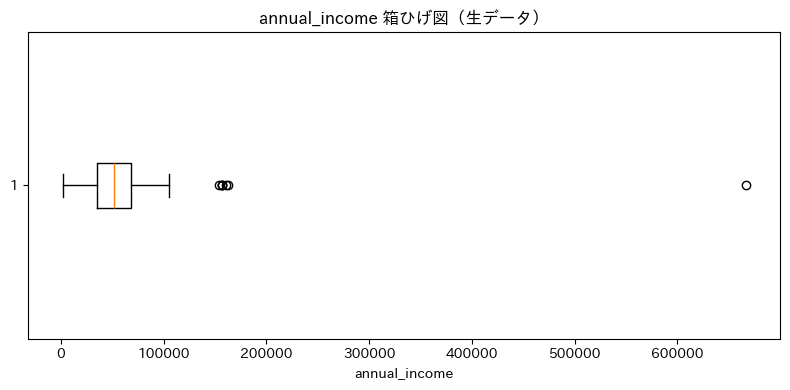

count      1553.000000
mean      52402.623954
std       26796.156599
min        1730.000000
25%       35196.000000
50%       51412.000000
75%       68657.000000
max      666666.000000
Name: annual_income, dtype: float64

99パーセンタイル: 95,014
666666の件数: 1


In [30]:
plt.figure(figsize=(8, 4))
plt.boxplot(train['annual_income'].dropna(), vert=False)
plt.title('annual_income 箱ひげ図（生データ）')
plt.xlabel('annual_income')
plt.tight_layout()
plt.show()

print(train['annual_income'].describe())
print(f'\n99パーセンタイル: {train["annual_income"].quantile(0.99):,.0f}')
print(f'666666の件数: {(train["annual_income"] == 666666).sum()}')

In [31]:
#欠損値ありと年収の関係
# 補完前のtrainで確認（前処理セルより前に実行する必要あり）
train_raw = pd.read_csv(PATH + 'train.csv')

train_raw['income_missing'] = train_raw['annual_income'].isna().astype(int)
missing_rate = train_raw.groupby('income_missing')['target'].mean()
print(missing_rate)
print(f"\n欠損あり反応率: {missing_rate[1]:.3f}")
print(f"欠損なし反応率: {missing_rate[0]:.3f}")
print(f"差: {missing_rate[1] - missing_rate[0]:+.3f}")

income_missing
0    0.150032
1    0.066667
Name: target, dtype: float64

欠損あり反応率: 0.067
欠損なし反応率: 0.150
差: -0.083


In [32]:
#① 欠損値の補完
median_income = train['annual_income'].median()
cap_income = train['annual_income'].quantile(0.99)
for df in [train, test]:
    df['annual_income'] = df['annual_income'].fillna(median_income)
    #annual_incomeの外れ値除去(中央値変換)
    df['annual_income'] = df['annual_income'].replace(666666, median_income)
    #150000超えの4件フラグ
    df['income_very_high'] = (df['annual_income'] > 150000).astype(int)
    df['annual_income'] = df['annual_income'].clip(upper=cap_income)# annual_income  クリッピング

In [33]:
# ② customer_tenure を先に計算（registration_date が必要）
for df in [train, test]:
    df['customer_tenure'] = 2024 - pd.to_datetime(df['registration_date'], errors='coerce').dt.year
    df['reg_year'] = pd.to_datetime(df['registration_date'], errors='coerce').dt.year
median_tenure = train['customer_tenure'].median()
for df in [train, test]:
    df['customer_tenure'] = df['customer_tenure'].fillna(median_tenure)
    df['income_missing'] = df['annual_income'].isna().astype(int)

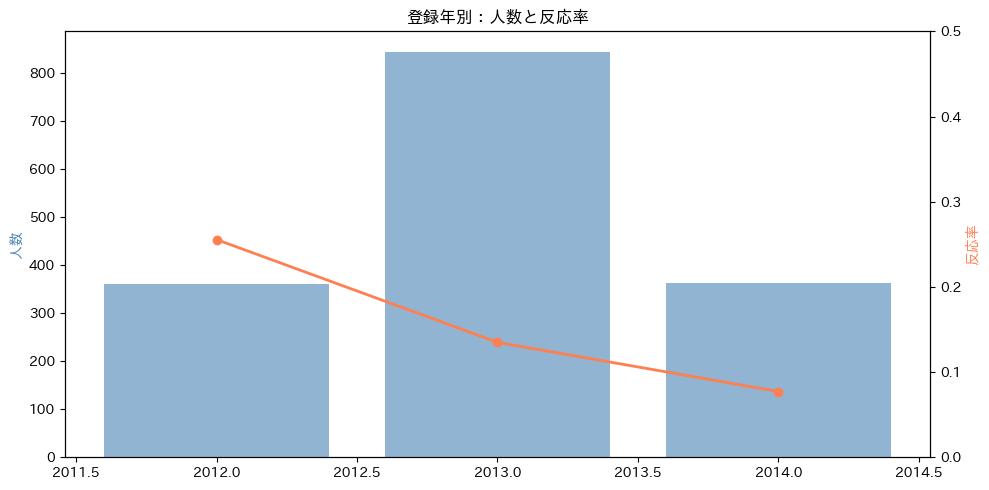

               反応率   人数
reg_year               
2012      0.255556  360
2013      0.134911  845
2014      0.077135  363


In [34]:
train_raw2 = pd.read_csv(PATH + 'train.csv')
train_raw2['reg_year'] = pd.to_datetime(train_raw2['registration_date'], errors='coerce').dt.year

target_by_year = train_raw2.groupby('reg_year')['target'].agg(['mean', 'count'])
target_by_year.columns = ['反応率', '人数']

fig, ax1 = plt.subplots(figsize=(10, 5))

# 棒グラフ：人数
ax1.bar(target_by_year.index, target_by_year['人数'], color='steelblue', alpha=0.6, label='人数')
ax1.set_ylabel('人数', color='steelblue')

# 折れ線：反応率
ax2 = ax1.twinx()
ax2.plot(target_by_year.index, target_by_year['反応率'], color='coral', marker='o', linewidth=2, label='反応率')
ax2.set_ylabel('反応率', color='coral')
ax2.set_ylim(0, 0.5)

plt.title('登録年別：人数と反応率')
plt.tight_layout()
plt.show()

print(target_by_year)

In [35]:
# ③ 不要列の削除
for df in [train, test]:
    df.drop(columns=['customer_id', 'registration_date'], inplace=True, errors='ignore')




In [36]:
# ④ 順序エンコーディング（学歴順）
from sklearn.preprocessing import OrdinalEncoder

edu_order = [['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']]

oe = OrdinalEncoder(categories=edu_order, handle_unknown='use_encoded_value', unknown_value=-1)
train['education_level'] = oe.fit_transform(train[['education_level']].astype(str)).astype(int)
test['education_level'] = oe.transform(test[['education_level']].astype(str)).astype(int)

# marital_statusはラベルエンコーディングのまま
le = LabelEncoder()
train['marital_status'] = le.fit_transform(train['marital_status'].astype(str))
test['marital_status'] = le.transform(test['marital_status'].astype(str))

print(train['education_level'].value_counts().sort_index())
print(train['education_level'].unique())

education_level
0     40
1    143
2    771
3    261
4    353
Name: count, dtype: int64
[2 4 3 1 0]


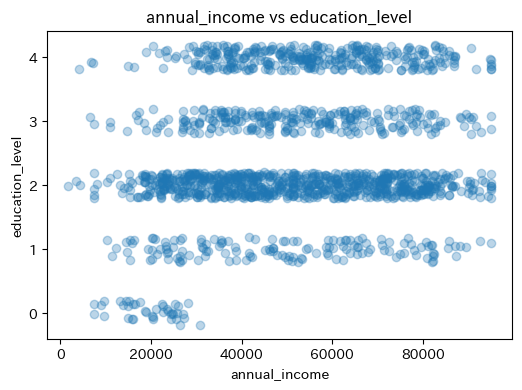

In [37]:
#2軸散布図
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.scatter(train['annual_income'],
             train['education_level'] + np.random.uniform(-0.2, 0.2, len(train)),  # jitter
            alpha=0.3)
#alpha=0.3（透明度）と jitter（縦方向にランダムにずらす）を加えることで、重なりが解消されて傾向が見えやすくなります。
plt.xlabel('annual_income')
plt.ylabel('education_level')
plt.title('annual_income vs education_level')
plt.show()

# 2軸散布図

#edu_order = ['Below College', 'College', 'Bachelor', 'Master', 'Doctor']
#edu_numeric = train['education_level'].map({v: i for i, v in enumerate(edu_order)})


#plt.figure(figsize=(6, 4))
#plt.scatter(train['annual_income'],
            #edu_numeric + np.random.uniform(-0.2, 0.2, len(train)),
            #alpha=0.3)
#plt.xlabel('annual_income')
#plt.yticks(range(len(edu_order)), edu_order)
#plt.ylabel('education_level')
#plt.title('annual_income vs education_level')
#plt.show()

In [38]:
# ④ ラベルエンコーディング（文字列→数値）
for col in ['education_level', 'marital_status']:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

#Target Encoding
te_cols = ['education_level', 'marital_status']

def cv_auc_with_te(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr = y.iloc[tr_idx]

# fold内の学習データだけでtarget平均を計算
        for col in te_cols:
            means = y_tr.groupby(X_tr[col]).mean()
            global_mean = y_tr.mean()
            X_tr[col] = X_tr[col].map(means)
            X_va[col] = X_va[col].map(means).fillna(global_mean)

        m = clone(model)
        m.fit(X_tr, y_tr)
        p = m.predict_proba(X_va)[:, 1]
        scores.append(roc_auc_score(y_va, p))
    return np.mean(scores), scores

In [39]:
###ベースラインモデルの構築　RandomForest と過学習
X = train.drop(columns=['target'])
y = train['target']

# 4章用に一時的にエンコード（文字列列だけ）
X_base = X.copy()
for col in ['education_level', 'marital_status']:
    le = LabelEncoder()
    X_base[col] = le.fit_transform(X_base[col].astype(str))

X_tr, X_va, y_tr, y_va = train_test_split(X_base, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr)
train_auc = roc_auc_score(y_tr, rf.predict_proba(X_tr)[:, 1])
valid_auc = roc_auc_score(y_va, rf.predict_proba(X_va)[:, 1])
print(f'Train AUC = {train_auc:.4f}')
print(f'Valid AUC = {valid_auc:.4f}')

Train AUC = 0.9999
Valid AUC = 0.8146


In [40]:
for d in [None, 10, 5, 3]:
    m = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42).fit(X_tr, y_tr)
    tr = roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1])
    va = roc_auc_score(y_va, m.predict_proba(X_va)[:, 1])
    print(f'max_depth={str(d):>4}:  Train={tr:.4f}  Valid={va:.4f}  gap={tr-va:.4f}')

max_depth=None:  Train=0.9999  Valid=0.8146  gap=0.1853
max_depth=  10:  Train=0.9995  Valid=0.8191  gap=0.1803
max_depth=   5:  Train=0.9549  Valid=0.8185  gap=0.1364
max_depth=   3:  Train=0.8779  Valid=0.8019  gap=0.0759


In [41]:
###5foldクロスバリデーション
def cv_auc(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[va_idx], p))
    return np.mean(scores), scores

rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
baseline_cv, folds = cv_auc(rf, X, y)
print('各foldのAUC:', [f'{s:.4f}' for s in folds])
print(f'基準スコア（CV平均AUC）= {baseline_cv:.4f}')

各foldのAUC: ['0.8825', '0.8040', '0.8499', '0.8541', '0.8128']
基準スコア（CV平均AUC）= 0.8407


In [65]:
###特徴量エンジニアリング
spend_cols = ['spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold']
for df in [train, test]:
    df['age'] = 2024 - df['birth_year']  # 基準年は便宜上の固定値。大小関係が保てればよい
    df['total_spend'] = df[spend_cols].sum(axis=1)  # spend_* 6列の合計
    df["children_total"] = df["num_children"] + df["num_teenagers"] #子供のデータ
    df["Ratio_of_totalspend_to_income"] = df["total_spend"] / df["annual_income"]  #所得に対する総消費
    df["Use_whithin_month"] = (df['days_since_last_purchase'] <= 60).astype(int)
    # 総購入回数（チャネル合計）
    df['total_purchases'] = df['web_purchases'] + df['catalog_purchases'] + df['store_purchases'] + df['deals_purchases']
    # 割引購入の比率（割引依存度）
    df['deals_ratio'] = df['deals_purchases'] / (df['total_purchases'] + 1)
    # 1購入あたりの消費額（購買効率）
    df['spend_per_purchase'] = df['total_spend'] / (df['total_purchases'] + 1)
    # 子供ありフラグ
    df['has_children'] = (df['children_total'] > 0).astype(int)

    # 収入を子供数で割った「1人あたり可処分所得」的な値
    df['income_per_member'] = df['annual_income'] / (df['children_total'] + 1)
    # 高齢×高消費の交差特徴
    df['age_x_spend'] = df['age'] * df['total_spend']
    df['web_conversion'] = df['web_purchases'] / (df['monthly_web_visits'] + 1)
    df['wine_ratio']   = df['spend_wines']  / (df['total_spend'] + 1)
    df['meat_ratio']   = df['spend_meat']   / (df['total_spend'] + 1)
    df['gold_ratio']   = df['spend_gold']   / (df['total_spend'] + 1)
    df['income_x_gold'] = df['annual_income'] * df['spend_gold']
    df['recency_x_spend'] = df['days_since_last_purchase'] * df['total_spend']
    df['income_x_education_level'] = df['annual_income'] * df['education_level']
    df['income_x_marital_status'] = df['annual_income'] * df['marital_status']
    df['income_x_age'] = df['annual_income'] * df['age']
    df['income_x_spend_meat'] = df['annual_income'] * df['spend_meat']
    df['meat_gift'] = df['catalog_purchases'] * df['spend_meat']
    df['reg_year_2012'] = (df['reg_year'] == 2012).astype(int)
    df['marital_x_children'] = df['marital_status'] * df['children_total']
    df['meat_div_age'] = df['spend_meat'] / (df['age'] + 1) # 若×肉
    df['age_x_gold'] = df['age'] * df['spend_gold']
    df['store_div_age'] = df['store_purchases'] / (df['age'] + 1) # 年齢×ストア
    df['store_x_children'] = df['store_purchases'] * df['has_children']
    df['age_x_sweets'] = df['age'] * df['spend_sweets']
    df['no_complaint'] = (df['has_complaint'] == 0).astype(int)
    df['income_x_children'] = df['annual_income'] * df['children_total']
    df['income_per_member_x_days_since_last_purchase'] = df['income_per_member'] * df['days_since_last_purchase']
    df['income_per_member_x_age'] = df['income_per_member'] * df['age']
    df['web_conversion_x_age'] = df['web_conversion'] * df['age']
    df['web_conversion_x_income_per_member'] = df['web_conversion'] * df['income_per_member']




X = train.drop(columns=['target'])
y = train['target']
print(X.columns.tolist())
X_fillterd = X

['birth_year', 'education_level', 'marital_status', 'annual_income', 'num_children', 'num_teenagers', 'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'has_complaint', 'income_very_high', 'customer_tenure', 'reg_year', 'income_missing', 'age', 'total_spend', 'children_total', 'Ratio_of_totalspend_to_income', 'Use_whithin_month', 'total_purchases', 'deals_ratio', 'spend_per_purchase', 'has_children', 'income_per_member', 'age_x_spend', 'web_conversion', 'wine_ratio', 'meat_ratio', 'gold_ratio', 'income_x_gold', 'recency_x_spend', 'income_x_education_level', 'income_x_marital_status', 'income_x_age', 'income_x_spend_meat', 'meat_gift', 'reg_year_2012', 'marital_x_children', 'meat_div_age', 'age_x_gold', 'store_div_age', 'store_x_children', 'age_x_sweets', 'no_complaint', 'income_x_children', 'income_per_member_x_days_since_l

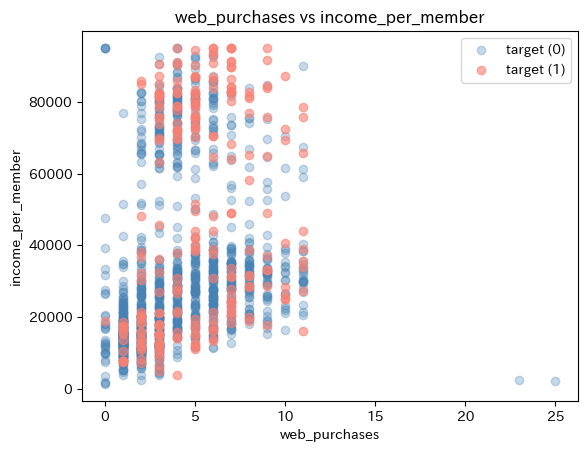

In [66]:
import matplotlib.pyplot as plt

# （target=0）
plt.scatter(train[train['target'] == 0]['web_purchases'],
            train[train['target'] == 0]['income_per_member'],
            alpha=0.3, color='steelblue', label='target (0)')

# （target=1）
plt.scatter(train[train['target'] == 1]['web_purchases'],
            train[train['target'] == 1]['income_per_member'],
            alpha=0.6, color='salmon', label='target (1)')

plt.xlabel('web_purchases')
plt.ylabel('income_per_member')
plt.title('web_purchases vs income_per_member')
plt.legend()
plt.show()

In [67]:
#カテゴリ値によって反応率に差があれば、Target Encoding（カテゴリ値を target 平均で置き換える手法）
def cv_auc_with_te(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr = y.iloc[tr_idx]
        y_va = y.iloc[va_idx]

        for col in te_cols:
            means = y_tr.groupby(X_tr[col]).mean()
            global_mean = y_tr.mean()
            X_tr[col] = X_tr[col].map(means)
            X_va[col] = X_va[col].map(means).fillna(global_mean)

        m = clone(model)
        m.fit(X_tr, y_tr)
        p = m.predict_proba(X_va)[:, 1]
        scores.append(roc_auc_score(y_va, p))
    return np.mean(scores), scores

lgbm_base = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                            random_state=42, verbose=-1)
te_cv, _ = cv_auc_with_te(lgbm_base, X, y)
print(f'Target Encoding CV AUC = {te_cv:.4f}  （現状 {baseline_cv:.4f}, 差 {te_cv - baseline_cv:+.4f}）')

Target Encoding CV AUC = 0.8611  （現状 0.8407, 差 +0.0205）


In [68]:
#null importanceで特徴量削除
drop_cols = ['gold_ratio','spend_wines','spend_fish','income_per_member','spend_sweets']

#X = X.drop(columns=drop_cols)


In [69]:
X = train.drop(columns=['target'])
y = train['target']
#X = X.drop(columns=[c for c in drop_cols if c in X.columns])
fe_cv, _ = cv_auc(rf, X, y)
print(f'特徴量追加後 CV AUC = {fe_cv:.4f}  （基準 {baseline_cv:.4f}, 差 {fe_cv - baseline_cv:+.4f}）')

特徴量追加後 CV AUC = 0.8376  （基準 0.8407, 差 -0.0031）


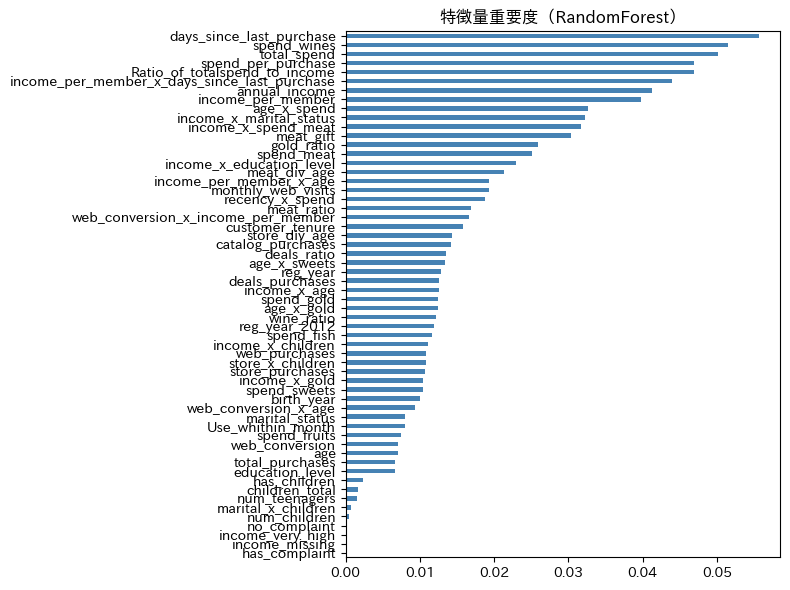

In [70]:
# 特徴量重要度: モデルがどの列をよく分岐に使ったかを見る
imp_model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42).fit(X, y)
importances = pd.Series(imp_model.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('特徴量重要度（RandomForest）')
plt.tight_layout()
plt.show()

In [71]:
###7. 様々なモデルの構築と比較
# 不均衡対策: 評価はAUC（順位指標）、ロジスティック回帰は class_weight='balanced' を使用
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42),
    'LogisticRegression': make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    'LightGBM': LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
        random_state=42, verbose=-1),
    'MLP': make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
        eval_metric='logloss', random_state=42),
    'CatBoost': CatBoostClassifier(n_estimators=300, learning_rate=0.05, depth=4,
        random_state=42, verbose=0),  # verbose=0で学習ログを非表示
}

cv_scores = {}
for name, model in models.items():
    mean_auc, _ = cv_auc(model, X, y)
    cv_scores[name] = mean_auc
    print(f'{name:20s} CV AUC = {mean_auc:.4f}')

RandomForest         CV AUC = 0.8376
LogisticRegression   CV AUC = 0.8594
LightGBM             CV AUC = 0.8577
MLP                  CV AUC = 0.8206
XGBoost              CV AUC = 0.8626
CatBoost             CV AUC = 0.8620


In [72]:
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


In [73]:
best_name = max(cv_scores, key=cv_scores.get)
print(f'\nこのデータで最も良かったモデル: {best_name}（CV AUC = {cv_scores[best_name]:.4f}）')


このデータで最も良かったモデル: XGBoost（CV AUC = 0.8626）


In [74]:
###8.モデルのアンサンブリング
#def cv_auc_ensemble(model_list, X, y, n_splits=5):
    #skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    #scores = []
    #for tr_idx, va_idx in skf.split(X, y):
        #preds = np.zeros(len(va_idx))
        #for model in model_list:
            #m = clone(model).fit(X.iloc[tr_idx], y.iloc[tr_idx])
            #preds += m.predict_proba(X.iloc[va_idx])[:, 1]
        #preds /= len(model_list)
        #scores.append(roc_auc_score(y.iloc[va_idx], preds))
    #return np.mean(scores)

# LightGBM / XGBoost / RandomForest を選んだ理由:
# 単体で強く、かつ学習アルゴリズムが異なるので「間違い方が分散」しやすい組み合わせ
#ens_models = [models['LightGBM'], models['XGBoost'], models['RandomForest']]
#ens_cv = cv_auc_ensemble(ens_models, X, y)


def cv_auc_ensemble_te(model_list, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
        y_tr = y.iloc[tr_idx]
        y_va = y.iloc[va_idx]
        for col in te_cols:
            means = y_tr.groupby(X_tr[col]).mean()
            X_tr[col] = X_tr[col].map(means)
            X_va[col] = X_va[col].map(means).fillna(y_tr.mean())
        preds = np.zeros(len(va_idx))
        for model in model_list:
            m = clone(model)
            m.fit(X_tr, y_tr)
            preds += m.predict_proba(X_va)[:, 1]
        preds /= len(model_list)
        scores.append(roc_auc_score(y_va, preds))
    return np.mean(scores)

# LightGBM / XGBoost / RandomForest を選んだ理由:
# 単体で強く、かつ学習アルゴリズムが異なるので「間違い方が分散」しやすい組み合わせ
ens_models = [models['LightGBM'], models['XGBoost'], models['RandomForest']]
ens_cv = cv_auc_ensemble_te(ens_models, X, y)

print(f'アンサンブル(単純平均) CV AUC = {ens_cv:.4f}')

アンサンブル(単純平均) CV AUC = 0.8682


In [75]:
from sklearn.ensemble import StackingClassifier

stack = StackingClassifier(
    estimators=[('lgbm', models['LightGBM']), ('xgb', models['XGBoost']), ('rf', models['RandomForest'])],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)
stack_cv, _ = cv_auc(stack, X, y)
print(f'スタッキング CV AUC = {stack_cv:.4f}')

スタッキング CV AUC = 0.8615


In [76]:
#9.ハイパーパラメータチューニング — Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 63),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 80),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    )
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    #mean_auc, _ = cv_auc(model, X, y)
    mean_auc, _ = cv_auc_with_te(model, X, y)
    return mean_auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}  （基準 {baseline_cv:.4f}, 差 {study.best_value - baseline_cv:+.4f}）')


  0%|          | 0/200 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8768  （基準 0.8407, 差 +0.0362）


In [77]:
#XGBoostOptunaでチューニング
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        max_depth=trial.suggest_int('max_depth', 3, 8),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        eval_metric='logloss',
        random_state=42,
    )
    model = XGBClassifier(**params)
    #mean_auc, _ = cv_auc(model, X, y)
    mean_auc, _ = cv_auc_with_te(model, X, y)
    return mean_auc

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=200, show_progress_bar=True)
print(f'XGBoost Optuna CV AUC = {study_xgb.best_value:.4f}')

  0%|          | 0/200 [00:00<?, ?it/s]

XGBoost Optuna CV AUC = 0.8803


In [78]:
#CATBOOSTOptunaでチューニング
def objective_cat(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        depth=trial.suggest_int('depth', 3, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bylevel=trial.suggest_float('colsample_bylevel', 0.6, 1.0),
        min_data_in_leaf=trial.suggest_int('min_data_in_leaf', 10, 80),
        random_state=42,
        verbose=0,
    )
    model = CatBoostClassifier(**params)
    #mean_auc, _ = cv_auc(model, X, y)
    mean_auc, _ = cv_auc_with_te(model, X, y)
    return mean_auc

study_cat = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=200, show_progress_bar=True)
print(f'CatBoost Optuna CV AUC = {study_cat.best_value:.4f}')

  0%|          | 0/200 [00:00<?, ?it/s]

CatBoost Optuna CV AUC = 0.8765


In [79]:
tuned_lgbm = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
tuned_xgb = XGBClassifier(**study_xgb.best_params, random_state=42)
tuned_cat = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=0)
#rf = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)

ens_models = [tuned_lgbm, tuned_xgb, tuned_cat]#, rf]
ens_cv = cv_auc_ensemble_te(ens_models, X, y)
print(f'チューニング済みアンサンブル CV AUC = {ens_cv:.4f}')

チューニング済みアンサンブル CV AUC = 0.8820


/tmp/ipykernel_8344/953306836.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, labels=top20[::-1],


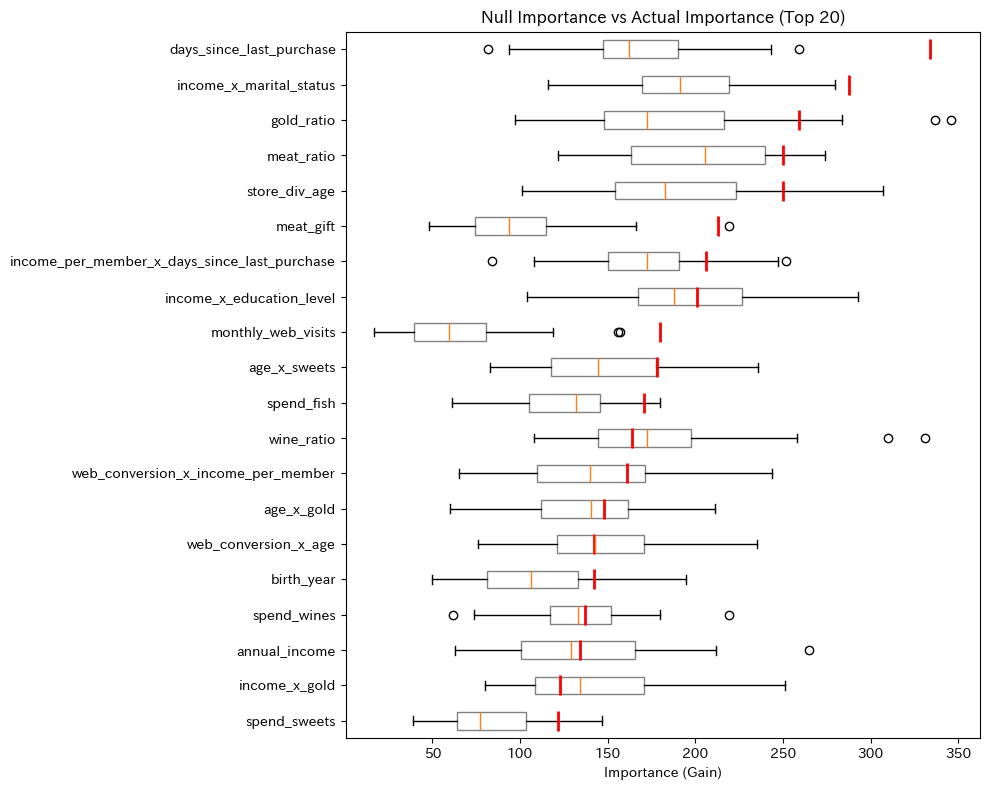

有用な特徴量(24個): ['birth_year', 'education_level', 'marital_status', 'num_teenagers', 'days_since_last_purchase', 'spend_fish', 'spend_sweets', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'customer_tenure', 'reg_year', 'age', 'Use_whithin_month', 'total_purchases', 'meat_ratio', 'gold_ratio', 'income_x_marital_status', 'meat_gift', 'reg_year_2012', 'store_div_age', 'store_x_children', 'income_per_member_x_days_since_last_purchase']
削除候補(34個): ['annual_income', 'num_children', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_gold', 'deals_purchases', 'has_complaint', 'income_very_high', 'income_missing', 'total_spend', 'children_total', 'Ratio_of_totalspend_to_income', 'deals_ratio', 'spend_per_purchase', 'has_children', 'income_per_member', 'age_x_spend', 'web_conversion', 'wine_ratio', 'income_x_gold', 'recency_x_spend', 'income_x_education_level', 'income_x_age', 'income_x_spend_meat', 'marital_x_children', 'meat_div_age', 'age_x_gold', 'age_x_sweets

In [80]:
#null importance
def null_importance(X, y, n_runs=50, random_state=42):
    model = LGBMClassifier(**study.best_params, random_state=random_state, verbose=-1)

    # 本物のimportance
    model.fit(X, y)
    real_imp = pd.Series(model.feature_importances_, index=X.columns)

    # Null importance
    null_imps = []
    for i in range(n_runs):
        y_shuffled = y.sample(frac=1, random_state=i).reset_index(drop=True)
        m = LGBMClassifier(**study.best_params, random_state=i, verbose=-1)
        m.fit(X, y_shuffled)
        null_imps.append(m.feature_importances_)

    null_imp_df = pd.DataFrame(null_imps, columns=X.columns)
    return real_imp, null_imp_df

real_imp, null_imp_df = null_importance(X, y, n_runs=50)

# 本物importanceの上位20列を表示
top20 = real_imp.sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 8))
data_to_plot = [null_imp_df[col].values for col in top20[::-1]]  # 上が高い順
plt.boxplot(data_to_plot, vert=False, labels=top20[::-1],
            patch_artist=True, boxprops=dict(facecolor='white', color='gray'))

# 実際のimportanceを赤線で重ねる
for i, col in enumerate(top20[::-1]):
    plt.plot(real_imp[col], i + 1, '|', color='red', markersize=15, markeredgewidth=2)

plt.xlabel('Importance (Gain)')
plt.title('Null Importance vs Actual Importance (Top 20)')
plt.tight_layout()
plt.show()

# useful_features の抽出
scores = {}
for col in X.columns:
    scores[col] = (null_imp_df[col] < real_imp[col]).mean()

useful_features = [col for col, s in scores.items() if s >= 0.8]
print(f'有用な特徴量({len(useful_features)}個): {useful_features}')
drop_cols = [col for col in X.columns if col not in useful_features]
print(f'削除候補({len(drop_cols)}個): {drop_cols}')

/tmp/ipykernel_8344/1324546906.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, vert=False, labels=top20[::-1],


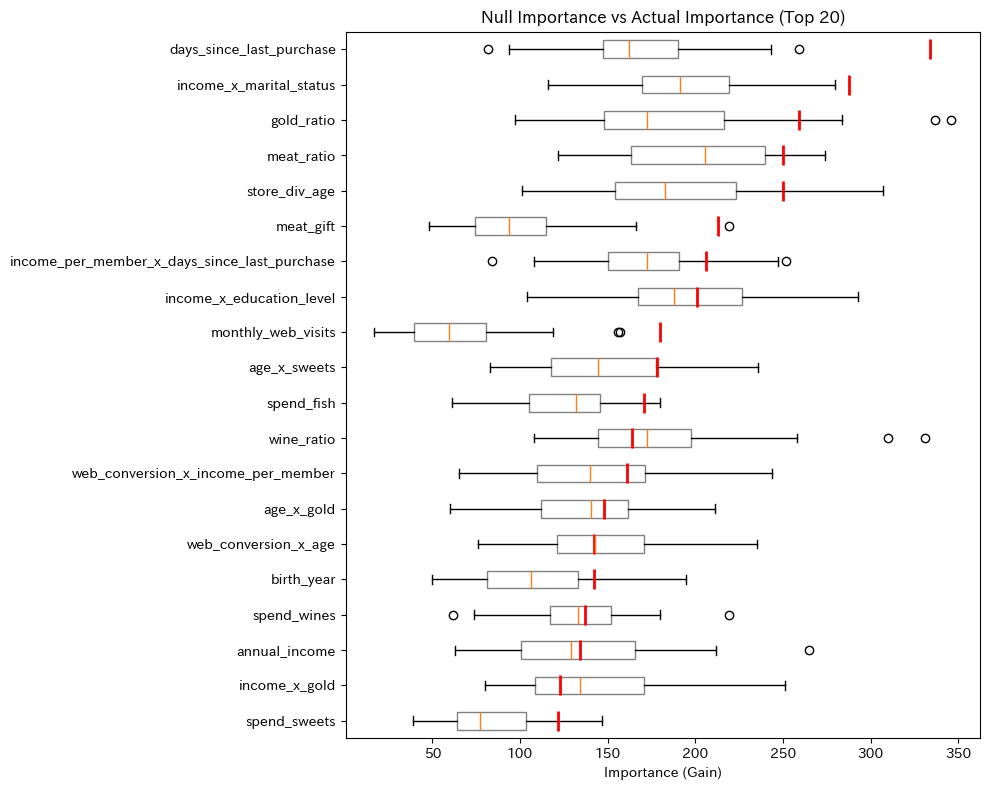

有用な特徴量(24個): ['birth_year', 'education_level', 'marital_status', 'num_teenagers', 'days_since_last_purchase', 'spend_fish', 'spend_sweets', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'customer_tenure', 'reg_year', 'age', 'Use_whithin_month', 'total_purchases', 'meat_ratio', 'gold_ratio', 'income_x_marital_status', 'meat_gift', 'reg_year_2012', 'store_div_age', 'store_x_children', 'income_per_member_x_days_since_last_purchase']
削除候補(34個): ['annual_income', 'num_children', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_gold', 'deals_purchases', 'has_complaint', 'income_very_high', 'income_missing', 'total_spend', 'children_total', 'Ratio_of_totalspend_to_income', 'deals_ratio', 'spend_per_purchase', 'has_children', 'income_per_member', 'age_x_spend', 'web_conversion', 'wine_ratio', 'income_x_gold', 'recency_x_spend', 'income_x_education_level', 'income_x_age', 'income_x_spend_meat', 'marital_x_children', 'meat_div_age', 'age_x_gold', 'age_x_sweets

In [81]:
#null importance2
def null_importance(X_fillterd, y, n_runs=50, random_state=42):
    model = LGBMClassifier(**study.best_params, random_state=random_state, verbose=-1)

    # 本物のimportance
    model.fit(X_fillterd, y)
    real_imp = pd.Series(model.feature_importances_, index= X_fillterd.columns)

    # Null importance
    null_imps = []
    for i in range(n_runs):
        y_shuffled = y.sample(frac=1, random_state=i).reset_index(drop=True)
        m = LGBMClassifier(**study.best_params, random_state=i, verbose=-1)
        m.fit(X_fillterd, y_shuffled)
        null_imps.append(m.feature_importances_)

    null_imp_df = pd.DataFrame(null_imps, columns=X.columns)
    return real_imp, null_imp_df

real_imp, null_imp_df = null_importance(X_fillterd, y, n_runs=50)

# 本物importanceの上位20列を表示
top20 = real_imp.sort_values(ascending=False).head(20).index

plt.figure(figsize=(10, 8))
data_to_plot = [null_imp_df[col].values for col in top20[::-1]]  # 上が高い順
plt.boxplot(data_to_plot, vert=False, labels=top20[::-1],
            patch_artist=True, boxprops=dict(facecolor='white', color='gray'))

# 実際のimportanceを赤線で重ねる
for i, col in enumerate(top20[::-1]):
    plt.plot(real_imp[col], i + 1, '|', color='red', markersize=15, markeredgewidth=2)

plt.xlabel('Importance (Gain)')
plt.title('Null Importance vs Actual Importance (Top 20)')
plt.tight_layout()
plt.show()

# useful_features の抽出
scores = {}
for col in X_fillterd.columns:
    scores[col] = (null_imp_df[col] < real_imp[col]).mean()

useful_features = [col for col, s in scores.items() if s >= 0.8]
print(f'有用な特徴量({len(useful_features)}個): {useful_features}')
drop_cols = [col for col in X_fillterd.columns if col not in useful_features]
print(f'削除候補({len(drop_cols)}個): {drop_cols}')

In [82]:
print(drop_cols)
print(f'X の列数: {X.shape[1]}')
print(X.describe())

['annual_income', 'num_children', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_gold', 'deals_purchases', 'has_complaint', 'income_very_high', 'income_missing', 'total_spend', 'children_total', 'Ratio_of_totalspend_to_income', 'deals_ratio', 'spend_per_purchase', 'has_children', 'income_per_member', 'age_x_spend', 'web_conversion', 'wine_ratio', 'income_x_gold', 'recency_x_spend', 'income_x_education_level', 'income_x_age', 'income_x_spend_meat', 'marital_x_children', 'meat_div_age', 'age_x_gold', 'age_x_sweets', 'no_complaint', 'income_x_children', 'income_per_member_x_age', 'web_conversion_x_age', 'web_conversion_x_income_per_member']
X の列数: 58
        birth_year  education_level  marital_status  annual_income  \
count  1568.000000      1568.000000     1568.000000    1568.000000   
mean   1968.823342         2.474490        2.195153   51739.345408   
std      12.023484         1.017705        1.478258   20790.855757   
min    1893.000000         0.000000        0.000000    1730

In [83]:
# ベスト設定で 5-fold それぞれ学習し、test 予測を平均する（k-fold アンサンブル）
##X_test = test[X.columns]  # train と同じ特徴量・順序に揃える
#skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#test_pred = np.zeros(len(test))
#for tr_idx, va_idx in skf.split(X, y):
    #m = LGBMClassifier(**study.best_params, random_state=42, verbose=-1)
    #m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    #test_pred += m.predict_proba(X_test)[:, 1] / skf.n_splits
#print('ベスト設定:', study.best_params)

## ベスト設定で 5-fold アンサンブルでtest予測
X_test = test[X.columns]

SEEDS = [42, 2024, 777]

#skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_pred = np.zeros(len(test))

# 各モデルのCV AUCを重みに使う
w_lgbm = study.best_value
w_xgb  = study_xgb.best_value
w_cat  = study_cat.best_value
w_total = w_lgbm + w_xgb + w_cat

for seed in SEEDS:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    for tr_idx, va_idx in skf.split(X, y):
        X_tr, X_te = X.iloc[tr_idx].copy(), X_test.copy()
        y_tr = y.iloc[tr_idx]

        # fold内でTarget Encoding
        for col in te_cols:
            means = y_tr.groupby(X_tr[col]).mean()
            global_mean = y_tr.mean()
            X_tr[col] = X_tr[col].map(means)
            X_te[col] = X_te[col].map(means).fillna(global_mean)

        # LightGBM
        lgbm_params = {**study.best_params, 'random_state': seed}
        lgbm = LGBMClassifier(**lgbm_params, verbose=-1)
        lgbm.fit(X_tr, y_tr)
        test_pred += lgbm.predict_proba(X_te)[:, 1] * (w_lgbm / w_total) / (skf.n_splits * len(SEEDS))

        # XGBoost
        xgb_params = {**study_xgb.best_params, 'random_state': seed}
        xgb = XGBClassifier(**xgb_params)
        xgb.fit(X_tr, y_tr)
        test_pred += xgb.predict_proba(X_te)[:, 1] * (w_xgb / w_total) / (skf.n_splits * len(SEEDS))

        # RandomForest
        #rf_m = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
        #rf_m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        #test_pred += rf_m.predict_proba(X_test)[:, 1] / (skf.n_splits * 4)

        # CatBoost
        cat_params = {**study_cat.best_params, 'random_state': seed}
        cat = CatBoostClassifier(**cat_params, verbose=0)
        cat.fit(X_tr, y_tr)
        test_pred += cat.predict_proba(X_te)[:, 1] * (w_cat / w_total) / (skf.n_splits * len(SEEDS))

print(f'重み: LGBM={w_lgbm/w_total:.3f}, XGB={w_xgb/w_total:.3f}, CAT={w_cat/w_total:.3f}')
print('ベスト設定:', study.best_params)
print('ベスト値:', study.best_value)
print(f'使用シード: {SEEDS}')

重み: LGBM=0.333, XGB=0.334, CAT=0.333
ベスト設定: {'n_estimators': 471, 'learning_rate': 0.024063195950785758, 'num_leaves': 59, 'max_depth': 7, 'min_child_samples': 67, 'subsample': 0.9690915712621155, 'colsample_bytree': 0.8263016790995582, 'reg_lambda': 0.020483087122762835}
ベスト値: 0.8768110758035105


In [87]:
def cv_auc_ensemble_te_seeds(model_list, X, y, seeds, n_splits=5):
    """
    複数シードでOOF予測を作り、シード間で平均してから
    最後に1回だけAUCを計算する(=真のバギング効果を測る)
    """
    oof_preds_all_seeds = np.zeros((len(seeds), len(X)))

    for s_idx, seed in enumerate(seeds):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof_pred = np.zeros(len(X))

        for tr_idx, va_idx in skf.split(X, y):
            X_tr, X_va = X.iloc[tr_idx].copy(), X.iloc[va_idx].copy()
            y_tr = y.iloc[tr_idx]

            for col in te_cols:
                means = y_tr.groupby(X_tr[col]).mean()
                global_mean = y_tr.mean()
                X_tr[col] = X_tr[col].map(means)
                X_va[col] = X_va[col].map(means).fillna(global_mean)

            preds = np.zeros(len(va_idx))
            for model in model_list:
                m = clone(model)
                # モデルごとのrandom_stateもseedに合わせる
                if hasattr(m, 'random_state'):
                    m.set_params(random_state=seed)
                m.fit(X_tr, y_tr)
                preds += m.predict_proba(X_va)[:, 1]
            preds /= len(model_list)

            oof_pred[va_idx] = preds

        oof_preds_all_seeds[s_idx] = oof_pred
        seed_auc = roc_auc_score(y, oof_pred)
        print(f'  seed={seed}: OOF AUC = {seed_auc:.4f}')

    # シード間で予測を平均(=バギング)してから最終AUC計算
    averaged_pred = oof_preds_all_seeds.mean(axis=0)
    bagged_auc = roc_auc_score(y, averaged_pred)
    return bagged_auc, oof_preds_all_seeds

SEEDS = [42, 2024, 777]

print('=== 単一シード(42)のみ ===')
single_seed_auc, _ = cv_auc_ensemble_te_seeds([tuned_lgbm, tuned_xgb, tuned_cat], X, y, seeds=[42])
print(f'単一シード CV AUC = {single_seed_auc:.4f}')

print('\n=== 3シード バギング ===')
bagged_auc, _ = cv_auc_ensemble_te_seeds([tuned_lgbm, tuned_xgb, tuned_cat], X, y, seeds=SEEDS)
print(f'3シード バギング CV AUC = {bagged_auc:.4f}')

print(f'\n差: {bagged_auc - single_seed_auc:+.4f}')

=== 単一シード(42)のみ ===
  seed=42: OOF AUC = 0.8796
単一シード CV AUC = 0.8796

=== 3シード バギング ===
  seed=42: OOF AUC = 0.8796
  seed=2024: OOF AUC = 0.8706
  seed=777: OOF AUC = 0.8699
3シード バギング CV AUC = 0.8779

差: -0.0017


In [88]:
###10.予測の出力、提出
# ここまでの CV スコアを一覧で比較し、最も高いものを提出に使う
summary = {'RF基準(5章)': baseline_cv}
summary.update({f'{k}(7章)': v for k, v in cv_scores.items()})
summary['アンサンブル(8章)'] = ens_cv
summary['スタッキング(8章)'] = stack_cv
summary['Optunaチューニング(9章)'] = study.best_value
for k, v in sorted(summary.items(), key=lambda kv: -kv[1]):
    print(f'{k:24s} CV AUC = {v:.4f}')

アンサンブル(8章)               CV AUC = 0.8820
Optunaチューニング(9章)         CV AUC = 0.8768
XGBoost(7章)              CV AUC = 0.8626
CatBoost(7章)             CV AUC = 0.8620
スタッキング(8章)               CV AUC = 0.8615
LogisticRegression(7章)   CV AUC = 0.8594
LightGBM(7章)             CV AUC = 0.8577
RF基準(5章)                 CV AUC = 0.8407
RandomForest(7章)         CV AUC = 0.8376
MLP(7章)                  CV AUC = 0.8206


In [89]:
# 9章で作った test_pred（5-fold アンサンブルの平均予測）から提出ファイルを作る
submission = pd.read_csv(PATH + 'sample_submission.csv')
submission['target'] = test_pred
submission.to_csv(PATH + 'submission_advanced.csv', index=False)
print('提出行数:', len(submission))
print('target範囲:', round(submission['target'].min(), 3), '〜', round(submission['target'].max(), 3))
submission.head()

提出行数: 672
target範囲: 0.001 〜 0.856


,customer_id,target
0,1568,0.653448
1,1569,0.478951
2,1570,0.185198
3,1571,0.005063
4,1572,0.128686


In [90]:
# Google Colab からダウンロードする場合
from google.colab import files
files.download(PATH + 'submission_advanced.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>